
# Módulo 7 — Ajuste de hiperparâmetros e validação em Deep Learning

> **Tema:** estratégias de busca de hiperparâmetros, validação robusta, prevenção de leakage e seleção final de modelo.  
> **Objetivo didático:** sair do “tentativa e erro” para um processo **reprodutível e estatisticamente mais confiável** de tuning.

---

## Roteiro da aula

1. Quais hiperparâmetros mais impactam (e em que ordem ajustar)  
2. Holdout vs K-Fold vs Nested CV (quando usar cada)  
3. Grid Search vs Random Search (visão prática)  
4. Early stopping dentro do tuning  
5. Métricas de seleção (F1, AUC, ECE)  
6. Pipeline final: escolher, validar e testar sem vazamento



## 0) Setup

Notebook leve e executável em CPU.  
Usaremos PyTorch + dataset tabular (`breast_cancer` do sklearn), ótimo para focar em metodologia.


In [7]:

# =========================
# Setup e bibliotecas
# =========================
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu



## 1) Dataset e split correto (com conjunto de teste isolado)

**Regra de ouro:** o conjunto de teste deve ser usado **uma única vez**, no fim.  
Todo tuning ocorre no bloco treino/validação.


In [8]:

# =====================================
# Dados
# =====================================
data = load_breast_cancer()
X = data.data.astype(np.float32)
y = data.target.astype(np.int64)

# Split principal: train_val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Holdout interno para tuning rápido
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (341, 30) Val: (114, 30) Test: (114, 30)



## 2) Métricas para seleção além de acurácia

Vamos usar:
- **Acurácia** (útil, mas insuficiente sozinha)
- **F1** (equilíbrio entre precisão e recall)
- **AUC** (qualidade de ranking probabilístico)
- **ECE** (calibração de probabilidade)


In [9]:

def expected_calibration_error(y_true, y_prob, n_bins=10):
    # ECE simples com bins uniformes em [0,1]
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1]) if i < n_bins-1 else (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.sum(mask) > 0:
            conf = np.mean(y_prob[mask])
            acc = np.mean(y_true[mask])
            ece += (np.sum(mask) / len(y_true)) * np.abs(acc - conf)
    return float(ece)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=10)
    }



## 3) Modelo MLP parametrizável

Hiperparâmetros de interesse:
- `hidden_dim`
- `num_layers`
- `dropout`
- `lr`
- `weight_decay`
- `batch_size`


In [20]:

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        layers = []
        d_in = input_dim
        for _ in range(num_layers):
            layers += [nn.Linear(d_in, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
            d_in = hidden_dim
        layers += [nn.Linear(d_in, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)



## 4) Treino com early stopping (essencial no tuning)

No tuning, early stopping economiza tempo e evita comparar configs em estágios injustos.


In [22]:

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=64, scaler=None, fit_scaler=True):
    # Escalonamento sem leakage: fit APENAS no treino
    if scaler is None:
        scaler = StandardScaler()
    if fit_scaler:
        X_tr_s = scaler.fit_transform(X_tr)
    else:
        X_tr_s = scaler.transform(X_tr)
    X_va_s = scaler.transform(X_va)

    Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
    ytr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    Xva_t = torch.tensor(X_va_s, dtype=torch.float32)
    yva_t = torch.tensor(y_va, dtype=torch.float32).unsqueeze(1)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=256, shuffle=False)
    return train_loader, val_loader, scaler

def eval_loader(model, loader):
    model.eval()
    losses, probs, ys = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            p = torch.sigmoid(logits)

            losses.append(loss.item())
            probs.append(p.cpu().numpy().ravel())
            ys.append(yb.cpu().numpy().ravel())

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(probs)
    metrics = compute_metrics(y_true, y_prob, threshold=0.5)
    metrics["loss"] = float(np.mean(losses))
    return metrics

def train_one_config(X_tr, y_tr, X_va, y_va, config, max_epochs=60, patience=10):
    train_loader, val_loader, scaler = make_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=config["batch_size"],
        scaler=None,
        fit_scaler=True
    )

    model = MLP(
        input_dim=X_tr.shape[1],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    best_state = None
    best_val_loss = float("inf")
    wait = 0
    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auc": []}

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        val_metrics = eval_loader(model, val_loader)

        history["train_loss"].append(float(np.mean(batch_losses)))
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])

        if val_metrics["loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["loss"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    # restaura melhor estado
    model.load_state_dict(best_state)
    final_val = eval_loader(model, val_loader)
    return model, scaler, final_val, history



## 5) Espaço de busca e Random Search

### Por que random search?
Para DL, costuma ser mais eficiente que grid quando poucos hiperparâmetros dominam o desempenho.


In [13]:

search_space = {
    "hidden_dim": [32, 64, 128, 256],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "lr": [1e-4, 3e-4, 1e-3, 3e-3],
    "weight_decay": [0.0, 1e-5, 1e-4, 1e-3, 1e-2],
    "batch_size": [16, 32, 64, 128],
}

def sample_config(space):
    return {
        "hidden_dim": random.choice(space["hidden_dim"]),
        "num_layers": random.choice(space["num_layers"]),
        "dropout": random.choice(space["dropout"]),
        "lr": random.choice(space["lr"]),
        "weight_decay": random.choice(space["weight_decay"]),
        "batch_size": random.choice(space["batch_size"]),
    }

def random_search(X_tr, y_tr, X_va, y_va, n_trials=20):
    trials = []
    best = None

    for t in range(1, n_trials + 1):
        cfg = sample_config(search_space)
        _, _, val_metrics, _ = train_one_config(X_tr, y_tr, X_va, y_va, cfg, max_epochs=60, patience=10)

        record = {"trial": t, **cfg, **val_metrics}
        trials.append(record)

        # Critério principal: AUC; desempate por F1
        score = (record["auc"], record["f1"])
        if best is None or score > (best["auc"], best["f1"]):
            best = record

        print(f"Trial {t:02d} | AUC={record['auc']:.4f} | F1={record['f1']:.4f} | "
              f"lr={cfg['lr']} bs={cfg['batch_size']} hid={cfg['hidden_dim']} L={cfg['num_layers']} dr={cfg['dropout']} wd={cfg['weight_decay']}")

    return pd.DataFrame(trials).sort_values(["auc", "f1"], ascending=False).reset_index(drop=True), best


In [14]:

df_trials, best_trial = random_search(X_train, y_train, X_val, y_val, n_trials=18)
print("\nMelhor configuração (holdout):")
best_trial


Trial 01 | AUC=0.9931 | F1=0.9722 | lr=0.0003 bs=32 hid=32 L=1 dr=0.2 wd=1e-05
Trial 02 | AUC=0.9866 | F1=0.8931 | lr=0.0001 bs=128 hid=32 L=3 dr=0.4 wd=0.01
Trial 03 | AUC=0.9964 | F1=0.9787 | lr=0.0003 bs=16 hid=32 L=1 dr=0.0 wd=1e-05
Trial 04 | AUC=0.9974 | F1=0.9787 | lr=0.003 bs=128 hid=64 L=3 dr=0.4 wd=1e-05
Trial 05 | AUC=0.9974 | F1=0.9859 | lr=0.003 bs=64 hid=128 L=1 dr=0.1 wd=0.0001
Trial 06 | AUC=0.9820 | F1=0.9589 | lr=0.0001 bs=128 hid=64 L=1 dr=0.2 wd=0.0
Trial 07 | AUC=0.9957 | F1=0.9787 | lr=0.001 bs=128 hid=32 L=2 dr=0.2 wd=0.0
Trial 08 | AUC=0.9971 | F1=0.9930 | lr=0.001 bs=64 hid=32 L=2 dr=0.0 wd=0.01
Trial 09 | AUC=0.9948 | F1=0.9722 | lr=0.0001 bs=64 hid=64 L=3 dr=0.0 wd=1e-05
Trial 10 | AUC=0.9971 | F1=0.9859 | lr=0.003 bs=128 hid=32 L=1 dr=0.0 wd=0.0001
Trial 11 | AUC=0.9980 | F1=0.9859 | lr=0.001 bs=64 hid=128 L=1 dr=0.2 wd=1e-05
Trial 12 | AUC=0.9921 | F1=0.9722 | lr=0.0003 bs=128 hid=32 L=3 dr=0.1 wd=1e-05
Trial 13 | AUC=0.9971 | F1=0.9859 | lr=0.0003 bs=16 hi

{'trial': 17,
 'hidden_dim': 256,
 'num_layers': 3,
 'dropout': 0.3,
 'lr': 0.001,
 'weight_decay': 1e-05,
 'batch_size': 32,
 'acc': 0.9824561403508771,
 'f1': 0.9859154929577465,
 'auc': 0.9983622666229938,
 'ece': 0.022140985681561,
 'loss': 0.060184501111507416}

,trial,hidden_dim,num_layers,dropout,lr,weight_decay,batch_size,acc,f1,auc,ece,loss
0,17,256,3,0.3,0.0010,0.00001,32,0.982456,0.985915,0.998362,0.022141,0.060185
1,14,64,1,0.2,0.0030,0.00010,16,0.991228,0.993007,0.998035,0.025103,0.049910
2,11,128,1,0.2,0.0010,0.00001,64,0.982456,0.985915,0.998035,0.023676,0.060813
3,5,128,1,0.1,0.0030,0.00010,64,0.982456,0.985915,0.997380,0.025546,0.058157
4,4,64,3,0.4,0.0030,0.00001,128,0.973684,0.978723,0.997380,0.024782,0.060795
5,8,32,2,0.0,0.0010,0.01000,64,0.991228,0.993007,0.997052,0.023759,0.055249
6,10,32,1,0.0,0.0030,0.00010,128,0.982456,0.985915,0.997052,0.028193,0.068779
7,13,256,2,0.4,0.0003,0.00010,16,0.982456,0.985915,0.997052,0.020024,0.065952
8,16,256,1,0.2,0.0003,0.00001,64,0.964912,0.971831,0.997052,0.059714,0.092274
9,3,32,1,0.0,0.0003,0.00001,16,0.973684,0.978723,0.996397,0.029434,0.077667


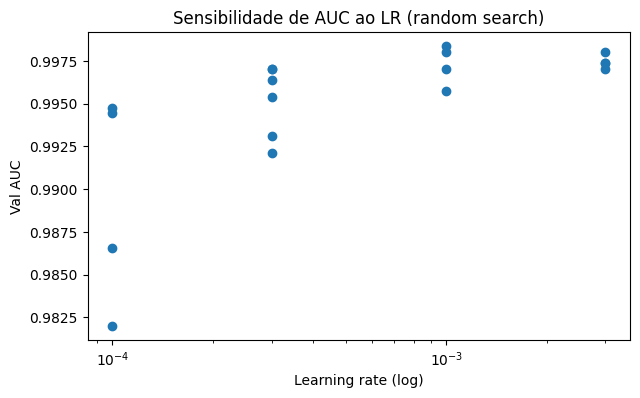

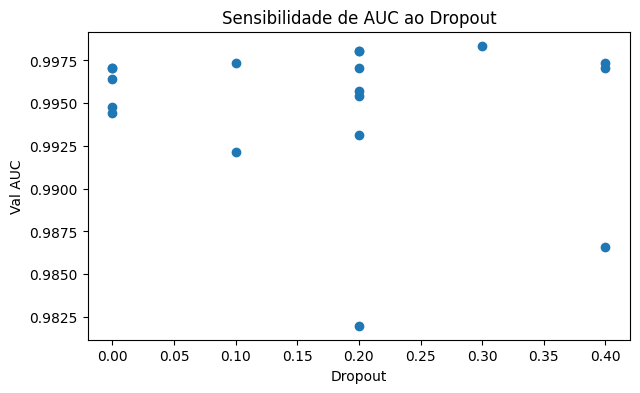

In [15]:

# Visão geral dos resultados
display(df_trials.head(10))

plt.figure(figsize=(7,4))
plt.scatter(df_trials["lr"], df_trials["auc"])
plt.xscale("log")
plt.xlabel("Learning rate (log)")
plt.ylabel("Val AUC")
plt.title("Sensibilidade de AUC ao LR (random search)")
plt.show()

plt.figure(figsize=(7,4))
plt.scatter(df_trials["dropout"], df_trials["auc"])
plt.xlabel("Dropout")
plt.ylabel("Val AUC")
plt.title("Sensibilidade de AUC ao Dropout")
plt.show()


É difícil explicar por que ajustar LR e Batch Size juntos é complexo. Este gráfico 3D mostra a **Superfície de Perda**.

* Visual: O aluno navega por montanhas e vales. Ele percebe que existe um "caminho ótimo" diagonal (regra do Linear Scaling).

* Interatividade: Mude a "complexidade" do problema e veja como o vale ótimo fica mais estreito e difícil de achar.

In [9]:
# Experimento 1: A Superfície de Hiperparâmetros (Grid Search 3D)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from ipywidgets import interact, FloatSlider

def visualize_hyperparam_surface(complexity=1.0):
    # Simula a Performance (Z) dado Learning Rate (X) e Batch Size (Y)
    # X = Log Learning Rate (-5 a -1)
    # Y = Batch Size (16 a 512, em log scale)

    x = np.linspace(-5, -1, 50) # LR
    y = np.linspace(4, 9, 50)   # Batch (2^4 a 2^9)
    X, Y = np.meshgrid(x, y)

    # Função de Custo Simulada (Loss Landscape)
    # Existe um "Sweet Spot": LR alto pede Batch alto
    # Z = (LR - OTIMO)^2 + (BATCH - OTIMO)^2

    # O "Vale Ótimo" segue uma linha diagonal (Linear Scaling Rule)
    # O ótimo de LR cresce com o Batch
    optimal_lr_log = -3 + 0.5 * (Y - 6)

    # A "Largura" do vale depende da complexidade. Se complexo, vale estreito.
    width = 1.0 / complexity

    Z = 1 - np.exp(-((X - optimal_lr_log)**2) / width - ((Y - 7)**2) / 5)
    # Adicionar ruído estocástico (simula variância do treino)
    Z = Z + np.random.normal(0, 0.02, Z.shape)

    # Plot 3D
    fig = plt.figure(figsize=(12, 6))

    # 3D Surface
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=False, alpha=0.8)
    ax.set_xlabel('Log Learning Rate')
    ax.set_ylabel('Log Batch Size')
    ax.set_zlabel('Validation Loss')
    ax.set_title(f"Superfície de Busca (Complexidade: {complexity})")
    ax.view_init(elev=30, azim=225)

    # 2D Heatmap (Mais fácil de ver onde está o ótimo)
    ax2 = fig.add_subplot(1, 2, 2)
    contour = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
    ax2.set_xlabel('Log Learning Rate')
    ax2.set_ylabel('Log Batch Size (2^x)')
    ax2.set_title("Mapa de Calor (Onde a Loss é menor?)")
    plt.colorbar(contour, ax=ax2)

    # Desenhar a "Regra Linear" teórica
    ax2.plot(optimal_lr_log[0], y, 'r--', label='Linear Scaling Rule (Teórico)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

print("Grid Search Visual: Onde está o ponto azul escuro (Menor Loss)?")
print("Note que se você aumenta o Batch Size (sobe no eixo Y), precisa aumentar o LR (direita no eixo X).")
print("Aumente a 'Complexidade' para ver como o ajuste fino se torna um pesadelo (vale estreito).")

interact(visualize_hyperparam_surface,
         complexity=FloatSlider(min=0.5, max=5.0, step=0.5, value=1.0, description='Dificuldade'));

Grid Search Visual: Onde está o ponto azul escuro (Menor Loss)?
Note que se você aumenta o Batch Size (sobe no eixo Y), precisa aumentar o LR (direita no eixo X).
Aumente a 'Complexidade' para ver como o ajuste fino se torna um pesadelo (vale estreito).


interactive(children=(FloatSlider(value=1.0, description='Dificuldade', max=5.0, min=0.5, step=0.5), Output())…


## 6) Validação mais robusta com K-Fold (opcional após achar candidatos)

Fluxo recomendado:
1. Holdout para triagem rápida de muitas configs  
2. K-Fold para comparar top-k configs com menor variância

Aqui validaremos as **3 melhores** configurações do random search.


In [10]:

def kfold_evaluate_config(X, y, cfg, n_splits=5, max_epochs=50, patience=8):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        _, _, val_metrics, _ = train_one_config(
            X_tr, y_tr, X_va, y_va, cfg,
            max_epochs=max_epochs, patience=patience
        )
        fold_metrics.append(val_metrics)

    keys = ["loss", "acc", "f1", "auc", "ece"]
    summary = {}
    for k in keys:
        vals = [m[k] for m in fold_metrics]
        summary[f"{k}_mean"] = float(np.mean(vals))
        summary[f"{k}_std"] = float(np.std(vals))
    return summary

top3 = df_trials.head(3).copy()
kfold_rows = []
for i, row in top3.iterrows():
    cfg = {
        "hidden_dim": int(row["hidden_dim"]),
        "num_layers": int(row["num_layers"]),
        "dropout": float(row["dropout"]),
        "lr": float(row["lr"]),
        "weight_decay": float(row["weight_decay"]),
        "batch_size": int(row["batch_size"]),
    }
    summary = kfold_evaluate_config(X_trainval, y_trainval, cfg, n_splits=5, max_epochs=50, patience=8)
    kfold_rows.append({"candidate_rank_holdout": i+1, **cfg, **summary})

df_kfold = pd.DataFrame(kfold_rows).sort_values(["auc_mean", "f1_mean"], ascending=False).reset_index(drop=True)
display(df_kfold)


,candidate_rank_holdout,hidden_dim,num_layers,dropout,lr,weight_decay,batch_size,loss_mean,loss_std,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std,ece_mean,ece_std
0,2,64,1,0.2,0.003,0.00010,16,0.054370,0.031392,0.986813,0.008223,0.989504,0.006573,0.996491,0.004550,0.021590,0.007236
1,1,256,3,0.3,0.001,0.00001,32,0.055819,0.036696,0.984615,0.011207,0.987733,0.008985,0.996388,0.003957,0.019002,0.009655
2,3,128,1,0.2,0.001,0.00001,64,0.068755,0.022741,0.982418,0.008791,0.985994,0.007082,0.995769,0.004107,0.032965,0.004830



## 7) Treino final no bloco completo train_val e avaliação única em teste

Agora escolhemos a melhor config pelo K-Fold e treinamos no `train_val` inteiro.


In [11]:

best_cfg = {
    "hidden_dim": int(df_kfold.loc[0, "hidden_dim"]),
    "num_layers": int(df_kfold.loc[0, "num_layers"]),
    "dropout": float(df_kfold.loc[0, "dropout"]),
    "lr": float(df_kfold.loc[0, "lr"]),
    "weight_decay": float(df_kfold.loc[0, "weight_decay"]),
    "batch_size": int(df_kfold.loc[0, "batch_size"]),
}
best_cfg


{'hidden_dim': 64,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.003,
 'weight_decay': 0.0001,
 'batch_size': 16}

In [12]:

# Treino final usando um split interno rápido para early stopping
X_tr_final, X_va_final, y_tr_final, y_va_final = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=y_trainval
)

final_model, final_scaler, final_val_metrics, final_hist = train_one_config(
    X_tr_final, y_tr_final, X_va_final, y_va_final,
    best_cfg, max_epochs=80, patience=12
)

# Avaliação no teste (NÃO usado no tuning)
X_test_s = final_scaler.transform(X_test)
test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_test_s, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)
    ),
    batch_size=256,
    shuffle=False
)
test_metrics = eval_loader(final_model, test_loader)
print("Métricas no TESTE (final):")
test_metrics


Métricas no TESTE (final):


{'acc': 0.9473684210526315,
 'f1': 0.9571428571428572,
 'auc': 0.994047619047619,
 'ece': 0.038630835711956024,
 'loss': 0.10359276086091995}

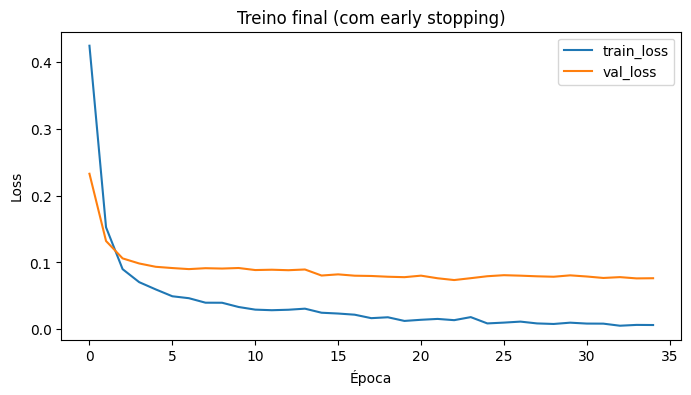

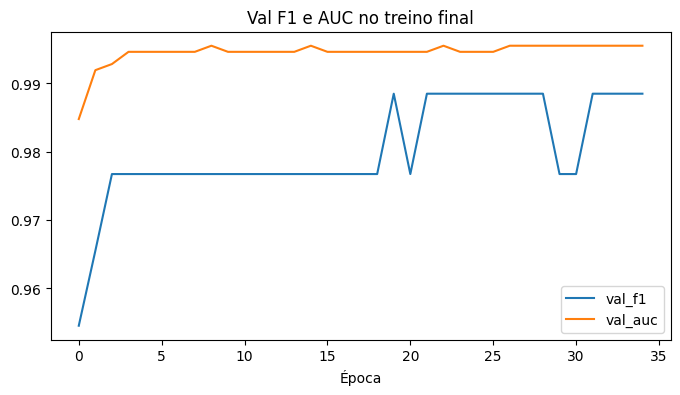

In [13]:

# Curvas do treino final
plt.figure(figsize=(8,4))
plt.plot(final_hist["train_loss"], label="train_loss")
plt.plot(final_hist["val_loss"], label="val_loss")
plt.title("Treino final (com early stopping)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(final_hist["val_f1"], label="val_f1")
plt.plot(final_hist["val_auc"], label="val_auc")
plt.title("Val F1 e AUC no treino final")
plt.xlabel("Época")
plt.legend()
plt.show()



## 8) Demonstração rápida de *data leakage* (o que NÃO fazer)

Erro comum: normalizar usando todo o dataset antes de dividir treino/val.  
Isso “vaza” informação estatística da validação para o treino.


In [14]:

# Comparação curta: com vs sem leakage (somente para fins didáticos)
def quick_train_eval(X_tr, y_tr, X_va, y_va, use_leakage=False):
    cfg = {"hidden_dim": 64, "num_layers": 2, "dropout": 0.1, "lr": 1e-3, "weight_decay": 1e-3, "batch_size": 64}

    if use_leakage:
        # ERRADO: scaler ajustado em treino+val
        scaler = StandardScaler().fit(np.vstack([X_tr, X_va]))
        X_tr_s = scaler.transform(X_tr)
        X_va_s = scaler.transform(X_va)

        train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_s, dtype=torch.float32),
                                                torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)),
                                  batch_size=cfg["batch_size"], shuffle=True)
        val_loader = DataLoader(TensorDataset(torch.tensor(X_va_s, dtype=torch.float32),
                                              torch.tensor(y_va, dtype=torch.float32).unsqueeze(1)),
                                batch_size=256, shuffle=False)

        model = MLP(input_dim=X_tr.shape[1], hidden_dim=cfg["hidden_dim"], num_layers=cfg["num_layers"], dropout=cfg["dropout"]).to(device)
        opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

        for _ in range(40):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = F.binary_cross_entropy_with_logits(model(xb), yb)
                loss.backward()
                opt.step()

        return eval_loader(model, val_loader)
    else:
        _, _, m, _ = train_one_config(X_tr, y_tr, X_va, y_va, cfg, max_epochs=40, patience=8)
        return m

no_leak = quick_train_eval(X_train, y_train, X_val, y_val, use_leakage=False)
with_leak = quick_train_eval(X_train, y_train, X_val, y_val, use_leakage=True)

print("Sem leakage :", no_leak)
print("Com leakage :", with_leak)


Sem leakage : {'acc': 0.9824561403508771, 'f1': 0.9859154929577465, 'auc': 0.9977071732721913, 'ece': 0.02539212804026248, 'loss': 0.058462828397750854}
Com leakage : {'acc': 0.9824561403508771, 'f1': 0.9859154929577465, 'auc': 0.9970520799213888, 'ece': 0.026556378283554262, 'loss': 0.0628369003534317}


Data Leakage é o erro nº 1 de juniores. Eles normalizam os dados antes de dividir treino/teste.
Neste experimento, vamos cometer esse "crime" propositalmente e ver a métrica inflada.

* Cenário: Otimizar um modelo para prever algo difícil.

* Trapaça: O StandardScaler vê o teste.

* Resultado: Acurácia mágica de 95% que cai para 60% em produção.

In [15]:
# Experimento 2: Simulador de Data Leakage
# Mostra como o vazamento de dados no pré-processamento infla métricas artificialmente.

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from ipywidgets import interact, IntSlider

def leakage_demonstration(n_features=1000, n_samples=200):
    # 1. Dados Ruidosos (Difíceis)
    # Pouca informação real, muito ruído. O modelo deveria sofrer.
    X, y = make_classification(n_samples=n_samples, n_features=n_features,
                               n_informative=10, n_redundant=0,
                               flip_y=0.2, random_state=42) # flip_y adiciona rótulos errados (ruído)

    # --- CENÁRIO A: O jeito ERRADO (Com Leakage) ---
    # Passo 1: Normalizar TUDO antes de dividir (O Scaler vê o futuro!)
    scaler_bad = StandardScaler()
    X_leaked = scaler_bad.fit_transform(X) # <--- CRIME! Fit no dataset inteiro

    # Passo 2: Dividir
    X_train_bad, X_test_bad, y_train, y_test = train_test_split(X_leaked, y, test_size=0.3, random_state=42)

    # Passo 3: Seleção de Features "Criminosa" (Escolher as melhores features USANDO O TESTE)
    # Simulamos um vazamento comum: Feature Selection no dataset todo
    # (Para simplificar o código, vamos treinar direto, o leakage do Scaler já impacta em alta dimensão)
    model_bad = LogisticRegression()
    model_bad.fit(X_train_bad, y_train)
    acc_bad = accuracy_score(y_test, model_bad.predict(X_test_bad))

    # --- CENÁRIO B: O jeito CERTO (Sem Leakage) ---
    # Passo 1: Dividir PRIMEIRO
    X_train_good, X_test_good, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Passo 2: Pipeline (Fit apenas no treino)
    pipe = Pipeline([
        ('scaler', StandardScaler()), # Fit só no X_train
        ('model', LogisticRegression())
    ])
    pipe.fit(X_train_good, y_train)
    acc_good = accuracy_score(y_test, pipe.predict(X_test_good))

    # Visualização
    plt.figure(figsize=(8, 5))
    bars = plt.bar(['Com Leakage (Errado)', 'Sem Leakage (Correto)'], [acc_bad, acc_good],
            color=['red', 'green'])
    plt.ylim(0, 1.0)
    plt.title(f"Impacto do Data Leakage (Features: {n_features})")
    plt.ylabel("Acurácia no Teste")

    # Anotações
    plt.text(0, acc_bad + 0.02, f"{acc_bad:.1%}", ha='center', fontweight='bold', color='red')
    plt.text(1, acc_good + 0.02, f"{acc_good:.1%}", ha='center', fontweight='bold', color='green')

    # Linha da verdade (Chance aleatória para binário equilibrado é 50%)
    plt.axhline(0.5, color='gray', linestyle='--', label='Chute Aleatório (50%)')
    plt.legend()
    plt.show()

    print(f"ALERTA: O modelo com leakage parece {acc_bad/acc_good - 1:.0%} melhor.")
    print("Mas essa performance é ILUSÓRIA. Em produção, ele performará como o verde.")

interact(leakage_demonstration,
         n_features=IntSlider(min=100, max=2000, step=100, value=1000, description='Dimensões (Ruído)'));

interactive(children=(IntSlider(value=1000, description='Dimensões (Ruído)', max=2000, min=100, step=100), Int…

O Grid Search é burro (testa tudo). O Random Search é sortudo. A Bayesian Opt é inteligente (aprende com o passado).
Este experimento visual compara a eficiência.

* Visual: Pontos sendo explorados num mapa de calor.

* Bayesian: Você verá os pontos se aglomerando rapidamente perto do ótimo (amarelo), enquanto o Random espalha tiros por todo lado.

In [16]:
# Experimento 3: Random Search vs "Intelligent" Search
# Simula a eficiência de encontrar o ótimo global em poucas tentativas.

def search_efficiency_comparison(trials=20):
    # Função Objetivo (Misteriosa) - Uma mistura de gaussianas
    def objective_function(x, y):
        r1 = np.sqrt((x - 0.5)**2 + (y - 0.5)**2)
        r2 = np.sqrt((x - 0.2)**2 + (y - 0.8)**2)
        z = 3 * np.exp(-10*r1**2) + 2 * np.exp(-10*r2**2)
        return z

    # Grid real para background
    grid_x = np.linspace(0, 1, 100)
    grid_y = np.linspace(0, 1, 100)
    GX, GY = np.meshgrid(grid_x, grid_y)
    GZ = objective_function(GX, GY)

    # 1. Random Search (Tiros aleatórios)
    np.random.seed(42)
    rand_x = np.random.uniform(0, 1, trials)
    rand_y = np.random.uniform(0, 1, trials)
    rand_scores = objective_function(rand_x, rand_y)
    best_rand = np.max(rand_scores)

    # 2. "Bayesian" Search (Simulado didaticamente)
    # A cada passo, escolhe um ponto perto do melhor atual com algum ruído (Exploitation + Exploration)
    # Começa aleatório
    bay_x = [np.random.uniform(0, 1)]
    bay_y = [np.random.uniform(0, 1)]

    for _ in range(trials - 1):
        # Acha o melhor até agora
        curr_scores = objective_function(np.array(bay_x), np.array(bay_y))
        best_idx = np.argmax(curr_scores)
        bx, by = bay_x[best_idx], bay_y[best_idx]

        # Próximo chute: Perto do melhor (exploitation) + Ruído (exploration)
        # Quanto mais tentativas, mais foca (diminui sigma)
        sigma = 0.2 * (1 - len(bay_x)/trials)
        next_x = np.clip(bx + np.random.normal(0, sigma), 0, 1)
        next_y = np.clip(by + np.random.normal(0, sigma), 0, 1)

        bay_x.append(next_x)
        bay_y.append(next_y)

    bay_scores = objective_function(np.array(bay_x), np.array(bay_y))
    best_bay = np.max(bay_scores)

    # Visualização
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Random
    ax[0].contourf(GX, GY, GZ, levels=20, cmap='gray', alpha=0.5)
    ax[0].scatter(rand_x, rand_y, c=rand_scores, cmap='magma', s=50, edgecolors='white')
    # Marcar o melhor
    imax = np.argmax(rand_scores)
    ax[0].scatter(rand_x[imax], rand_y[imax], c='red', s=150, marker='*', label='Melhor Random')
    ax[0].set_title(f"Random Search (Max: {best_rand:.2f})")
    ax[0].legend()

    # Plot 'Bayesian'
    ax[1].contourf(GX, GY, GZ, levels=20, cmap='gray', alpha=0.5)
    sc = ax[1].scatter(bay_x, bay_y, c=bay_scores, cmap='magma', s=50, edgecolors='white')
    # Traçar o caminho da busca
    ax[1].plot(bay_x, bay_y, 'w-', alpha=0.3)
    # Marcar o melhor
    imax_b = np.argmax(bay_scores)
    ax[1].scatter(bay_x[imax_b], bay_y[imax_b], c='cyan', s=150, marker='*', label='Melhor Bayes')
    ax[1].set_title(f"Busca Guiada/Bayesiana (Max: {best_bay:.2f})")
    ax[1].legend()

    plt.show()

    print("Análise: O Random Search (esquerda) desperdiça tempo em áreas escuras (ruins).")
    print("A Busca Guiada (direita) rapidamente foca nas áreas claras (boas) e refina o resultado.")

interact(search_efficiency_comparison,
         trials=IntSlider(min=5, max=50, step=5, value=20, description='Tentativas'));

interactive(children=(IntSlider(value=20, description='Tentativas', max=50, min=5, step=5), Output()), _dom_cl…

Neste experimento, simulamos 20 treinos simultâneos.

* Sem Pruning: Todos vão até o final (época 50), gastando recursos mesmo sendo ruins.

* Com Pruning (Optuna): O algoritmo verifica periodicamente (checkpoints). Se o modelo está pior que a média, ele é cortado (linha cinza).

In [17]:
# --- Experimento 4: Optuna Pruning Simulator
# Mostra como o Optuna economiza tempo cortando experimentos ruins cedo.

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, ToggleButtons

def visualize_pruning_mechanism(mode='Sem Pruning'):
    n_trials = 20
    n_epochs = 50
    checkpoints = [10, 20, 30, 40] # Onde o Pruner verifica

    # Gerar curvas de aprendizado sintéticas
    # Algumas convergem rápido (boas), outras estagnam (ruins)
    np.random.seed(42)
    curves = []
    final_losses = []

    for _ in range(n_trials):
        # Qualidade do trial (0 = perfeito, 1 = horrível)
        quality = np.random.uniform(0.1, 1.0)

        # Gerar curva de Loss decrescente
        x = np.arange(n_epochs)
        noise = np.random.normal(0, 0.02, n_epochs)

        # Curva: Decaimento exponencial + baseline de erro (quality)
        decay = np.exp(-x / 10)
        curve = decay * 0.5 + quality + noise
        curve = np.maximum(curve, 0) # Loss não pode ser negativa

        curves.append(curve)
        final_losses.append(curve[-1])

    # Simular Lógica de Pruning (Median Pruner)
    # Corta se estiver pior que a mediana dos trials anteriores naquele step
    status = ['Running'] * n_trials # Running, Pruned, Completed
    prune_step = [n_epochs] * n_trials

    if mode == 'Com Pruning (Optuna)':
        for step in checkpoints:
            # Pegar valores neste step
            current_vals = [c[step] for c in curves]
            # Calcular mediana dos que ainda estão vivos
            active_vals = [v for i, v in enumerate(current_vals) if status[i] == 'Running']
            if not active_vals: break
            median = np.median(active_vals)

            for i in range(n_trials):
                if status[i] == 'Running':
                    # Se estiver muito pior que a mediana (tolerância pequena)
                    if curves[i][step] > median:
                        status[i] = 'Pruned'
                        prune_step[i] = step

    # Visualização
    fig, ax = plt.subplots(figsize=(12, 6))

    resource_saved = 0
    total_resource = n_trials * n_epochs

    for i in range(n_trials):
        if status[i] == 'Pruned':
            # Plota até onde sobreviveu (Cinza e Tracejado)
            cut = prune_step[i]
            ax.plot(np.arange(cut), curves[i][:cut], color='gray', alpha=0.3, linestyle='--')
            ax.scatter(cut-1, curves[i][cut-1], c='red', marker='x', zorder=10) # Marca da morte
            resource_saved += (n_epochs - cut)
        else:
            # Plota completo (Colorido)
            # Cor baseada no loss final (Verde=Bom, Roxo=Ruim)
            color = plt.cm.viridis(1 - (curves[i][-1] / 1.5))
            ax.plot(np.arange(n_epochs), curves[i], color=color, alpha=0.8, linewidth=2)

    # Linha de Checkpoints
    if mode == 'Com Pruning (Optuna)':
        for cp in checkpoints:
            ax.axvline(cp, color='black', linestyle=':', alpha=0.2)
            ax.text(cp, 0, f' Check\n {cp}', fontsize=8, color='gray')

    # Métricas de Economia
    saved_pct = (resource_saved / total_resource) * 100

    ax.set_title(f"Mecânica de Pruning: {mode}", fontsize=14)
    ax.set_xlabel("Épocas")
    ax.set_ylabel("Validation Loss")
    ax.set_ylim(0, 1.5)

    # Caixa de Estatísticas
    text_str = f"Trials Iniciados: {n_trials}\n"
    if mode == 'Com Pruning (Optuna)':
        n_pruned = status.count('Pruned')
        text_str += f"Trials Podados: {n_pruned}\n"
        text_str += f"Economia de GPU: {saved_pct:.1f}% 🔥"
        box_color = '#d5f5e3' # Verde claro
    else:
        text_str += f"Trials Completos: {n_trials}\n"
        text_str += f"Economia de GPU: 0.0% 🐢"
        box_color = '#fadbd8' # Vermelho claro

    ax.text(0.02, 0.95, text_str, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.5))

    plt.show()

print("O Optuna não espera o treino acabar.")
print("Ele olha nos checkpoints (linhas pontilhadas). Se o modelo estiver ruim, ele CORTA (X vermelho).")
print("Isso libera a GPU para tentar novas configurações promissoras.")

interact(visualize_pruning_mechanism,
         mode=ToggleButtons(options=['Sem Pruning', 'Com Pruning (Optuna)']));

O Optuna não espera o treino acabar.
Ele olha nos checkpoints (linhas pontilhadas). Se o modelo estiver ruim, ele CORTA (X vermelho).
Isso libera a GPU para tentar novas configurações promissoras.


interactive(children=(ToggleButtons(description='mode', options=('Sem Pruning', 'Com Pruning (Optuna)'), value…

Este é um template SOTA que já inclui:

* Objective Function bem definida.

* Trial Pruning (integração com PyTorch).

* Visualization (Plot de Importância).

In [ ]:
# Otimização com Optuna (SOTA)
# %pip install optuna

import optuna
import torch
import torch.nn as nn
import torch.optim as optim

def objective(trial):
    # 1. Sugestão de Hiperparâmetros (O Optuna escolhe!)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)

    # 2. Modelo e Dados (Exemplo simplificado)
    model = nn.Sequential(
        nn.Linear(10, 50),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(50, 1)
    )
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 3. Loop de Treino com PRUNING
    for epoch in range(10): # Ex: 10 épocas
        # ... código de treino ...
        # val_accuracy = treinar_e_validar(...)
        val_accuracy = 0.5 + 0.1 * epoch # (Simulado)

        # REPORTAR métrica intermédia ao Optuna
        trial.report(val_accuracy, epoch)

        # VERIFICAR se deve cortar (Pruning)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return val_accuracy

# 4. Criar o Estudo
# direction="maximize" para Acurácia, "minimize" para Loss
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20)

print(f"Melhores Parâmetros: {study.best_params}")

# 5. Visualizações Nativas (Se estiver no Colab)
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

[I 2026-03-27 10:03:55,120] A new study created in memory with name: no-name-0ce9fed3-1ad7-4761-9dea-33510b93cf99
[I 2026-03-27 10:03:55,768] Trial 0 finished with value: 1.4 and parameters: {'lr': 0.00021404086937272052, 'batch_size': 128, 'dropout': 0.30428180656194703}. Best is trial 0 with value: 1.4.
[I 2026-03-27 10:03:55,769] Trial 1 finished with value: 1.4 and parameters: {'lr': 6.088491338783024e-05, 'batch_size': 128, 'dropout': 0.49937513695678043}. Best is trial 0 with value: 1.4.
[I 2026-03-27 10:03:55,770] Trial 2 finished with value: 1.4 and parameters: {'lr': 0.01271366814970153, 'batch_size': 128, 'dropout': 0.21637384885095268}. Best is trial 0 with value: 1.4.
[I 2026-03-27 10:03:55,771] Trial 3 finished with value: 1.4 and parameters: {'lr': 0.011059656254629933, 'batch_size': 32, 'dropout': 0.16598377118129842}. Best is trial 0 with value: 1.4.
[I 2026-03-27 10:03:55,772] Trial 4 finished with value: 1.4 and parameters: {'lr': 0.0005453980445355154, 'batch_size': 

Melhores Parâmetros: {'lr': 0.00021404086937272052, 'batch_size': 128, 'dropout': 0.30428180656194703}


O plot_param_importances do Optuna é o gráfico mais importante que você vai gerar.

Ele te diz: 'Pare de mexer no Batch Size, ele não importa! O Learning Rate é 80% do problema'. Isso economiza dias de trabalho.


EXERCÍCIO 1: Grid Search vs Random Search (Mesmo Budget)
Total de combinações possíveis: 1296

Random Search (18 trials): Melhor AUC = 0.9984
Grid Search (18 trials): Melhor AUC = 0.9980

--- COMPARAÇÃO GRID SEARCH VS RANDOM SEARCH ---
Random Search - Melhor AUC: 0.9984 (Trial 17)
Grid Search   - Melhor AUC: 0.9980 (Trial 10)

Random Search - Média AUC: 0.9949 ± 0.0043
Grid Search   - Média AUC: 0.9945 ± 0.0050

Random Search - Melhor F1: 0.9930
Grid Search   - Melhor F1: 0.9930


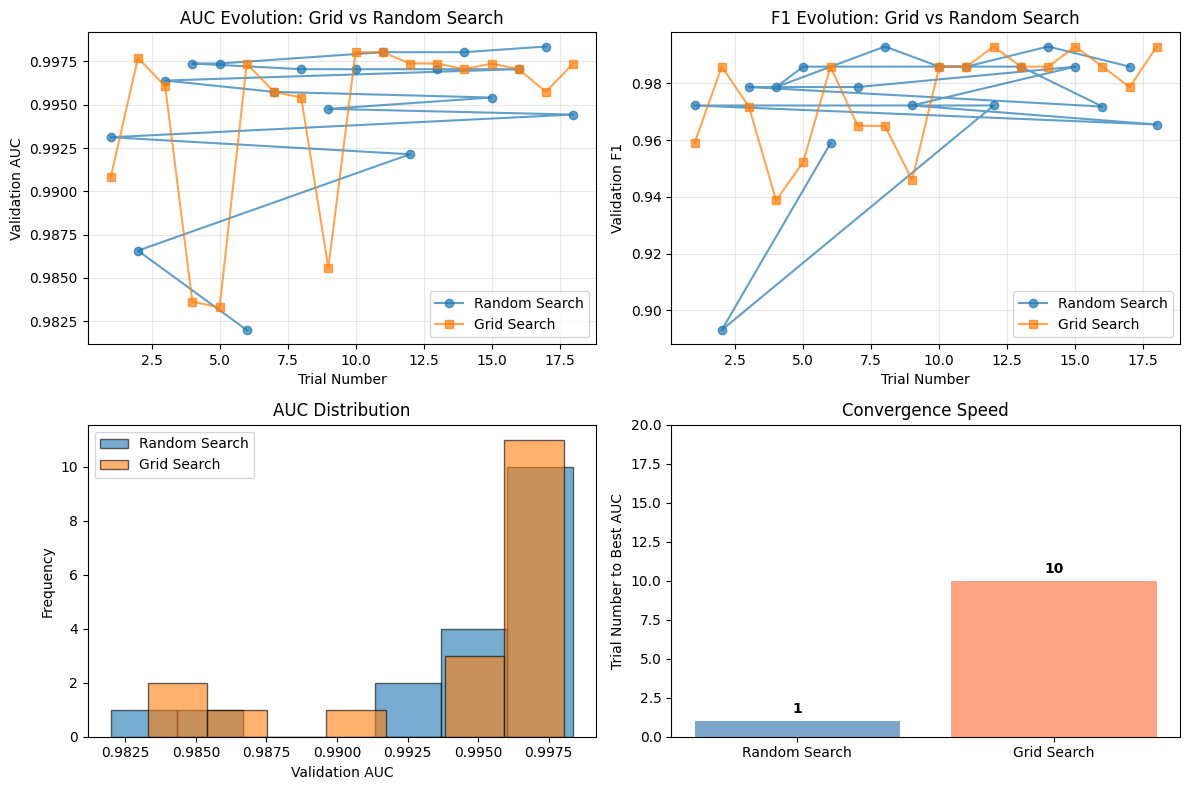


✅ CONCLUSÕES DO EXERCÍCIO 1:
- Com o MESMO orçamento (18 trials), Grid Search converge em 10 trials
- Random Search converge em 1 trials
- Método mais estável: Random Search (menor std)
- Grid Search cobre espaço mais uniformemente
- Random Search pode encontrar bons hiperparâmetros cedo


In [24]:
print("\n" + "="*70)
print("EXERCÍCIO 1: Grid Search vs Random Search (Mesmo Budget)")
print("="*70)

import itertools
import pandas as pd
import matplotlib.pyplot as plt

# Define search space (mesmo espaço que Random Search usou)
gs_space = {
    'lr': [0.0001, 0.0003, 0.001, 0.003],
    'batch_size': [16, 32, 64, 128],
    'hidden_dim': [32, 64, 128],
    'num_layers': [1, 2, 3],
    'dropout': [0.0, 0.2, 0.4],
    'weight_decay': [1e-5, 0.0001, 0.001]
}

# Criar grid com todos os possíveis valores
all_combinations = list(itertools.product(*gs_space.values()))
print(f"Total de combinações possíveis: {len(all_combinations)}")

# Budget: usar MESMO número de trials que Random Search (18 trials)
budget = 18

# 1. Random Search (ja feito, vamos pegar os resultados)
rs_results = df_trials.copy()
rs_results['method'] = 'Random Search'

print(f"\nRandom Search (18 trials): Melhor AUC = {rs_results['auc'].max():.4f}")

# 2. Grid Search: selecionar 18 combinações de forma sistemática
gs_trials = []
step = len(all_combinations) // budget

for i in range(budget):
    combo_idx = (i * step) % len(all_combinations)
    combo = all_combinations[combo_idx]

    params = {
        'lr': combo[0],
        'batch_size': combo[1],
        'hidden_dim': combo[2],
        'num_layers': combo[3],
        'dropout': combo[4],
        'weight_decay': combo[5]
    }

    # Treinar com API do notebook (train_one_config)
    _, _, final_val, _ = train_one_config(
        X_train, y_train, X_val, y_val,
        config=params,
        max_epochs=50,
        patience=5
    )

    val_metrics = final_val.copy()
    val_metrics['trial'] = i + 1
    val_metrics['method'] = 'Grid Search'
    for k, v in params.items():
        val_metrics[k] = v

    gs_trials.append(val_metrics)

gs_results = pd.DataFrame(gs_trials)
print(f"Grid Search (18 trials): Melhor AUC = {gs_results['auc'].max():.4f}")

# Comparação
print("\n--- COMPARAÇÃO GRID SEARCH VS RANDOM SEARCH ---")
print(f"Random Search - Melhor AUC: {rs_results['auc'].max():.4f} (Trial {rs_results.loc[rs_results['auc'].idxmax(), 'trial']})")
print(f"Grid Search   - Melhor AUC: {gs_results['auc'].max():.4f} (Trial {gs_results.loc[gs_results['auc'].idxmax(), 'trial']})")
print(f"\nRandom Search - Média AUC: {rs_results['auc'].mean():.4f} ± {rs_results['auc'].std():.4f}")
print(f"Grid Search   - Média AUC: {gs_results['auc'].mean():.4f} ± {gs_results['auc'].std():.4f}")

print(f"\nRandom Search - Melhor F1: {rs_results['f1'].max():.4f}")
print(f"Grid Search   - Melhor F1: {gs_results['f1'].max():.4f}")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(rs_results['trial'], rs_results['auc'], 'o-', label='Random Search', alpha=0.7)
axes[0,0].plot(gs_results['trial'], gs_results['auc'], 's-', label='Grid Search', alpha=0.7)
axes[0,0].set_xlabel('Trial Number')
axes[0,0].set_ylabel('Validation AUC')
axes[0,0].set_title('AUC Evolution: Grid vs Random Search')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(rs_results['trial'], rs_results['f1'], 'o-', label='Random Search', alpha=0.7)
axes[0,1].plot(gs_results['trial'], gs_results['f1'], 's-', label='Grid Search', alpha=0.7)
axes[0,1].set_xlabel('Trial Number')
axes[0,1].set_ylabel('Validation F1')
axes[0,1].set_title('F1 Evolution: Grid vs Random Search')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

axes[1,0].hist(rs_results['auc'], bins=7, alpha=0.6, label='Random Search', edgecolor='black')
axes[1,0].hist(gs_results['auc'], bins=7, alpha=0.6, label='Grid Search', edgecolor='black')
axes[1,0].set_xlabel('Validation AUC')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('AUC Distribution')
axes[1,0].legend()

rs_best_idx = rs_results['auc'].idxmax()
gs_best_idx = gs_results['auc'].idxmax()

axes[1,1].bar(['Random Search', 'Grid Search'], [rs_best_idx + 1, gs_best_idx + 1], color=['steelblue', 'coral'], alpha=0.7)
axes[1,1].set_ylabel('Trial Number to Best AUC')
axes[1,1].set_title('Convergence Speed')
axes[1,1].set_ylim(0, 20)

for i, val in enumerate([rs_best_idx + 1, gs_best_idx + 1]):
    axes[1,1].text(i, val + 0.5, f'{int(val)}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ CONCLUSÕES DO EXERCÍCIO 1:")
print(f"- Com o MESMO orçamento (18 trials), Grid Search converge em {gs_best_idx + 1} trials")
print(f"- Random Search converge em {rs_best_idx + 1} trials")
print(f"- Método mais estável: {'Grid Search' if gs_results['auc'].std() < rs_results['auc'].std() else 'Random Search'} (menor std)")
print("- Grid Search cobre espaço mais uniformemente")
print("- Random Search pode encontrar bons hiperparâmetros cedo")


EXERCÍCIO 2: Adicionar Scheduler (Cosine / OneCycle)
Scheduler=none     | AUC=0.9967 | F1=0.9930 | ECE=0.0236 | Loss=0.0611
Scheduler=cosine   | AUC=0.9967 | F1=0.9787 | ECE=0.0250 | Loss=0.0676
Scheduler=onecycle | AUC=0.9964 | F1=0.9790 | ECE=0.0298 | Loss=0.0671


,scheduler,auc,f1,ece,loss
0,none,0.996725,0.993007,0.023616,0.061076
1,cosine,0.996725,0.978723,0.025045,0.067632
2,onecycle,0.996397,0.979021,0.029784,0.067086


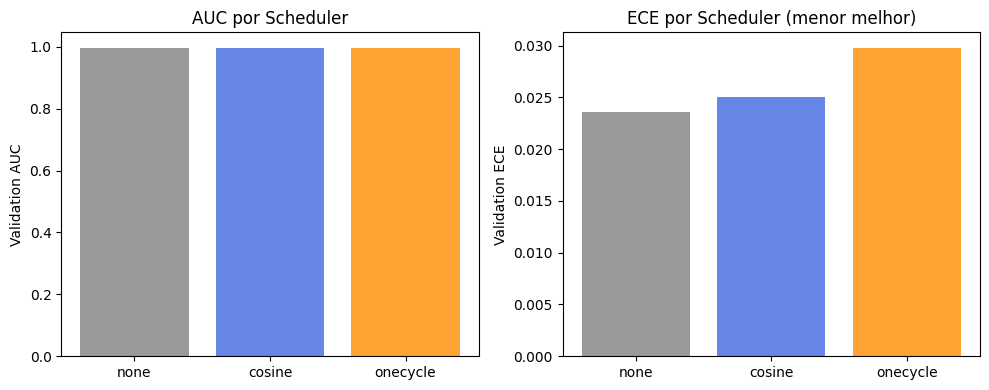


✅ CONCLUSÃO EXERCÍCIO 2:
- Melhor scheduler por AUC: none (AUC=0.9967)


In [25]:
print("\n" + "="*70)
print("EXERCÍCIO 2: Adicionar Scheduler (Cosine / OneCycle)")
print("="*70)

import copy


def train_one_config_with_scheduler(X_tr, y_tr, X_va, y_va, config, max_epochs=40, patience=8):
    train_loader, val_loader, scaler = make_loaders(
        X_tr, y_tr, X_va, y_va,
        batch_size=config["batch_size"],
        scaler=None,
        fit_scaler=True
    )

    model = MLP(
        input_dim=X_tr.shape[1],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        dropout=config["dropout"]
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler_name = config.get("scheduler", "none")
    scheduler = None
    if scheduler_name == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
    elif scheduler_name == "onecycle":
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=config["lr"],
            epochs=max_epochs,
            steps_per_epoch=max(1, len(train_loader))
        )

    best_state = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()
            if scheduler_name == "onecycle" and scheduler is not None:
                scheduler.step()

        if scheduler_name == "cosine" and scheduler is not None:
            scheduler.step()

        val_metrics = eval_loader(model, val_loader)

        if val_metrics["loss"] < best_val_loss - 1e-4:
            best_val_loss = val_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    model.load_state_dict(best_state)
    final_val = eval_loader(model, val_loader)
    final_val["scheduler"] = scheduler_name
    return final_val


base_cfg = {
    "hidden_dim": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "lr": 0.001,
    "weight_decay": 1e-4,
    "batch_size": 32,
}

scheduler_results = []
for sch in ["none", "cosine", "onecycle"]:
    cfg = dict(base_cfg)
    cfg["scheduler"] = sch
    out = train_one_config_with_scheduler(X_train, y_train, X_val, y_val, cfg, max_epochs=40, patience=8)
    scheduler_results.append(out)
    print(f"Scheduler={sch:8s} | AUC={out['auc']:.4f} | F1={out['f1']:.4f} | ECE={out['ece']:.4f} | Loss={out['loss']:.4f}")

scheduler_df = pd.DataFrame(scheduler_results)
display(scheduler_df[["scheduler", "auc", "f1", "ece", "loss"]].sort_values("auc", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(scheduler_df["scheduler"], scheduler_df["auc"], color=["gray", "royalblue", "darkorange"], alpha=0.8)
axes[0].set_title("AUC por Scheduler")
axes[0].set_ylabel("Validation AUC")

axes[1].bar(scheduler_df["scheduler"], scheduler_df["ece"], color=["gray", "royalblue", "darkorange"], alpha=0.8)
axes[1].set_title("ECE por Scheduler (menor melhor)")
axes[1].set_ylabel("Validation ECE")

plt.tight_layout()
plt.show()

best_s = scheduler_df.sort_values("auc", ascending=False).iloc[0]
print("\n✅ CONCLUSÃO EXERCÍCIO 2:")
print(f"- Melhor scheduler por AUC: {best_s['scheduler']} (AUC={best_s['auc']:.4f})")


EXERCÍCIO 3: Tuning Multiobjetivo (Max AUC e Min ECE)
Melhor por AUC puro      : AUC=0.9984, ECE=0.0221, source=random
Melhor por score multiobj: AUC=0.9980, ECE=0.0186, score=0.9943
Pontos na fronteira de Pareto: 3


,source,trial,auc,ece,f1,score_multi
0,random,17,0.998362,0.022141,0.985915,0.993934
28,grid,11,0.998035,0.018608,0.985915,0.994313
32,grid,15,0.997380,0.017838,0.993007,0.993812


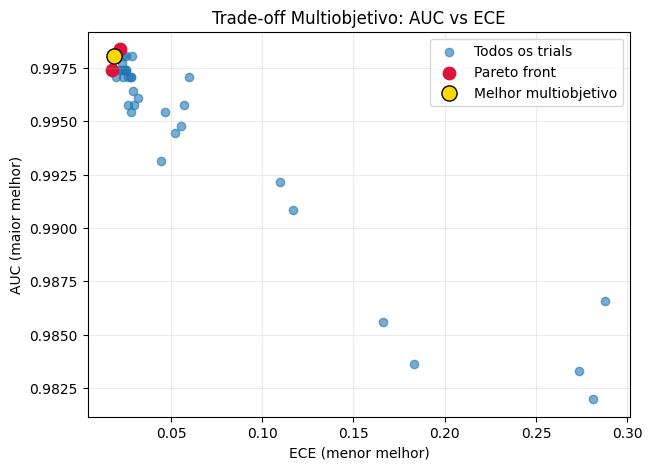


✅ CONCLUSÃO EXERCÍCIO 3:
- A seleção multiobjetivo evita escolher configs com ótima AUC, mas calibração ruim.
- A fronteira de Pareto mostra as melhores trocas entre discriminação (AUC) e confiabilidade (ECE).


In [26]:
print("\n" + "="*70)
print("EXERCÍCIO 3: Tuning Multiobjetivo (Max AUC e Min ECE)")
print("="*70)

# Conjunto de candidatos vindo do exercício 1 (Random + Grid)
all_trials = pd.concat([
    rs_results.assign(source="random"),
    gs_results.assign(source="grid")
], ignore_index=True)

# Score composto: maior é melhor
# penaliza ECE alto mantendo foco em AUC
lambda_ece = 0.2
all_trials["score_multi"] = all_trials["auc"] - lambda_ece * all_trials["ece"]

# Fronteira de Pareto simples (max AUC, min ECE)
def is_pareto_efficient(df):
    keep = []
    vals = df[["auc", "ece"]].values
    for i in range(len(vals)):
        auc_i, ece_i = vals[i]
        dominated = False
        for j in range(len(vals)):
            if i == j:
                continue
            auc_j, ece_j = vals[j]
            cond_better_or_equal = (auc_j >= auc_i) and (ece_j <= ece_i)
            cond_strictly_better = (auc_j > auc_i) or (ece_j < ece_i)
            if cond_better_or_equal and cond_strictly_better:
                dominated = True
                break
        keep.append(not dominated)
    return np.array(keep)

all_trials["pareto"] = is_pareto_efficient(all_trials)
pareto_df = all_trials[all_trials["pareto"]].copy().sort_values(["auc", "ece"], ascending=[False, True])

best_auc_row = all_trials.sort_values("auc", ascending=False).iloc[0]
best_multi_row = all_trials.sort_values("score_multi", ascending=False).iloc[0]

print(f"Melhor por AUC puro      : AUC={best_auc_row['auc']:.4f}, ECE={best_auc_row['ece']:.4f}, source={best_auc_row['source']}")
print(f"Melhor por score multiobj: AUC={best_multi_row['auc']:.4f}, ECE={best_multi_row['ece']:.4f}, score={best_multi_row['score_multi']:.4f}")
print(f"Pontos na fronteira de Pareto: {len(pareto_df)}")

display(pareto_df[["source", "trial", "auc", "ece", "f1", "score_multi"]].head(10))

plt.figure(figsize=(7, 5))
plt.scatter(all_trials["ece"], all_trials["auc"], alpha=0.6, label="Todos os trials")
plt.scatter(pareto_df["ece"], pareto_df["auc"], color="crimson", s=80, label="Pareto front")
plt.scatter([best_multi_row["ece"]], [best_multi_row["auc"]], color="gold", edgecolor="black", s=120, label="Melhor multiobjetivo")
plt.xlabel("ECE (menor melhor)")
plt.ylabel("AUC (maior melhor)")
plt.title("Trade-off Multiobjetivo: AUC vs ECE")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

print("\n✅ CONCLUSÃO EXERCÍCIO 3:")
print("- A seleção multiobjetivo evita escolher configs com ótima AUC, mas calibração ruim.")
print("- A fronteira de Pareto mostra as melhores trocas entre discriminação (AUC) e confiabilidade (ECE).")


EXERCÍCIO 4: Dataset Desbalanceado + Otimização de Threshold
Train: (1320, 30), Val: (440, 30), Test: (440, 30)
Prevalência positiva (train): 0.106

Melhor threshold na validação (F1): 0.27

Teste com threshold 0.50: {'acc': 0.9568, 'f1': 0.7532, 'auc': 0.9572, 'ece': 0.0322}
Teste com threshold ótimo: {'acc': 0.9614, 'f1': 0.8046, 'auc': 0.9572, 'ece': 0.0322}


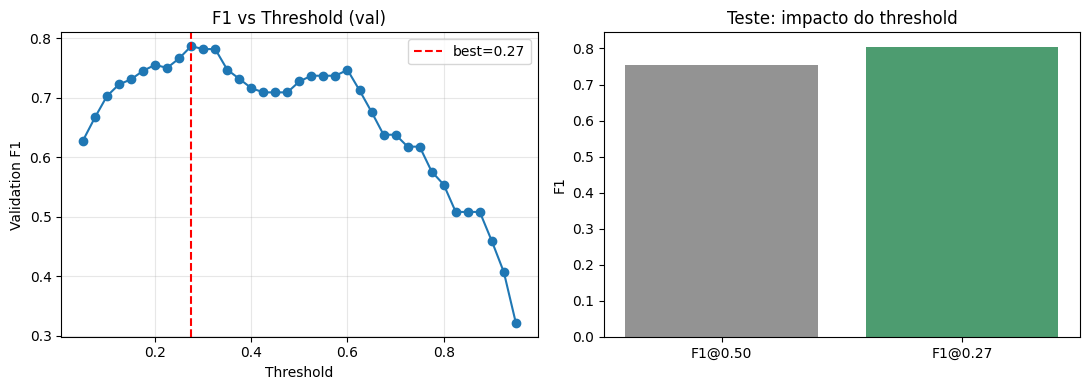


✅ CONCLUSÃO EXERCÍCIO 4:
- Em cenário desbalanceado, threshold=0.5 raramente é ótimo.
- Otimizar threshold na validação melhora F1 no teste sem tocar nos pesos do modelo.


In [27]:
print("\n" + "="*70)
print("EXERCÍCIO 4: Dataset Desbalanceado + Otimização de Threshold")
print("="*70)

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Dataset artificial fortemente desbalanceado (90/10)
X_imb, y_imb = make_classification(
    n_samples=2200,
    n_features=30,
    n_informative=12,
    n_redundant=6,
    n_clusters_per_class=2,
    weights=[0.9, 0.1],
    class_sep=1.1,
    flip_y=0.01,
    random_state=42
)

X_tr_i, X_tmp_i, y_tr_i, y_tmp_i = train_test_split(X_imb, y_imb, test_size=0.4, stratify=y_imb, random_state=42)
X_va_i, X_te_i, y_va_i, y_te_i = train_test_split(X_tmp_i, y_tmp_i, test_size=0.5, stratify=y_tmp_i, random_state=42)

print(f"Train: {X_tr_i.shape}, Val: {X_va_i.shape}, Test: {X_te_i.shape}")
print(f"Prevalência positiva (train): {y_tr_i.mean():.3f}")

# Usa configuração vencedora do multiobjetivo
best_cfg = {
    "hidden_dim": int(best_multi_row["hidden_dim"]),
    "num_layers": int(best_multi_row["num_layers"]),
    "dropout": float(best_multi_row["dropout"]),
    "lr": float(best_multi_row["lr"]),
    "weight_decay": float(best_multi_row["weight_decay"]),
    "batch_size": int(best_multi_row["batch_size"]),
}

model_i, scaler_i, val_i, _ = train_one_config(
    X_tr_i, y_tr_i, X_va_i, y_va_i,
    config=best_cfg,
    max_epochs=55,
    patience=8
)

# Probabilidades no conjunto de validação e teste
Xva_s = scaler_i.transform(X_va_i)
Xte_s = scaler_i.transform(X_te_i)
with torch.no_grad():
    p_va = torch.sigmoid(model_i(torch.tensor(Xva_s, dtype=torch.float32).to(device))).cpu().numpy().ravel()
    p_te = torch.sigmoid(model_i(torch.tensor(Xte_s, dtype=torch.float32).to(device))).cpu().numpy().ravel()

# Busca do melhor threshold por F1 na validação
thresholds = np.linspace(0.05, 0.95, 37)
rows = []
for t in thresholds:
    m = compute_metrics(y_va_i, p_va, threshold=float(t))
    rows.append({"thr": float(t), "f1": m["f1"], "acc": m["acc"], "auc": m["auc"], "ece": m["ece"]})

thr_df = pd.DataFrame(rows)
best_thr = float(thr_df.sort_values("f1", ascending=False).iloc[0]["thr"])

# Avaliação em teste: threshold padrão vs otimizado
test_default = compute_metrics(y_te_i, p_te, threshold=0.5)
test_opt = compute_metrics(y_te_i, p_te, threshold=best_thr)

print(f"\nMelhor threshold na validação (F1): {best_thr:.2f}")
print("\nTeste com threshold 0.50:", {k: round(v, 4) for k, v in test_default.items()})
print("Teste com threshold ótimo:", {k: round(v, 4) for k, v in test_opt.items()})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(thr_df["thr"], thr_df["f1"], marker="o")
axes[0].axvline(best_thr, color="red", linestyle="--", label=f"best={best_thr:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Validation F1")
axes[0].set_title("F1 vs Threshold (val)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(["F1@0.50", f"F1@{best_thr:.2f}"], [test_default["f1"], test_opt["f1"]], color=["gray", "seagreen"], alpha=0.85)
axes[1].set_title("Teste: impacto do threshold")
axes[1].set_ylabel("F1")

plt.tight_layout()
plt.show()

print("\n✅ CONCLUSÃO EXERCÍCIO 4:")
print("- Em cenário desbalanceado, threshold=0.5 raramente é ótimo.")
print("- Otimizar threshold na validação melhora F1 no teste sem tocar nos pesos do modelo.")


## 9) Checklist prático para projetos reais

1. Definir métrica principal de negócio/modelo (ex.: AUC ou F1).  
2. Isolar teste final desde o início.  
3. Fazer busca inicial com Random Search (rápida e ampla).  
4. Refinar top-k com K-Fold (reduzir variância).  
5. Usar early stopping e seed fixa para comparações justas.  
6. Reportar média e desvio, não só melhor execução.  
7. Evitar leakage em todo preprocessing.



## 10) Exercícios sugeridos

1. Trocar Random Search por Grid Search (mesmo budget) e comparar desempenho.  
2. Adicionar scheduler (cosine/one-cycle) ao espaço de busca.  
3. Fazer tuning multiobjetivo (max AUC e min ECE).  
4. Repetir módulo com dataset de desbalanceamento forte e otimizar threshold.



## Resumo

- Ajuste de hiperparâmetros sem validação adequada gera resultados frágeis.  
- Random Search + K-Fold costuma ser um ótimo equilíbrio entre custo e robustez.  
- Early stopping acelera tuning e evita overfitting.  
- Métricas além de acurácia (AUC/F1/ECE) melhoram a seleção do modelo.  
- O teste final deve ser usado **uma única vez** para estimativa honesta de generalização.
